# NicheSphere tutorial — Myocardial Infarction (Visium)

NicheSphere is an sc-verse compatible Python library for identifying differentially co-localised cellular niches and the biological processes driving their interactions, based on cell type pair co-localization probabilities across conditions.

Co-localization probabilities can be derived from:
- **Deconvoluted Visium / PIC-seq data** — probability of finding each cell type in each spot / multiplet
- **Single-cell resolved spatial data (MERFISH, CODEX, ...)** — counting cell boundary overlaps or radius-based neighborhoods per cell type pair

NicheSphere also supports localized process-based differential cell-cell communication analysis using Ligand-Receptor (LR) pair expression data from tools such as [LIANA](https://github.com/saezlab/liana-py) and [CrossTalkeR](https://github.com/CostaLab/CrossTalkeR).

**In this tutorial** we apply NicheSphere to the Myocardial Infarction (MI) Visium atlas from Kuppe et al., 2022, to identify cellular niches and communication changes between myogenic and ischemic heart tissue. We will:

1. Load and inspect the data
2. Compute cell type co-localization probabilities from Visium deconvolution results
3. Test differential co-localization between conditions and build a co-localization network
4. Detect niches and compute niche statistics
5. Load communication data and test localized process-based differential communication
6. Visualize differential communication networks and Sankey diagrams


## 1. Setup
import anndata as ad


In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import warnings
import scanpy as sc
import mudata as md
from community_layout.layout_class import CommunityLayout

warnings.filterwarnings("ignore")

import nichesphere


COMMUNITY LAYOUT: Datashader not found, edge bundling not available


### Download data

All data files for this tutorial are available on Zenodo.

Please open a **Terminal** (or Command Line) in the NicheSphere root folder if you cloned the repo from Github and run the following command to download and extract the dataset:

```bash 
wget https://zenodo.org/records/21806024/files/data.zip && unzip data.zip && rm data.zip
```

This will download `data.zip`, extract its contents into the `NicheSphere/data/` folder, and automatically remove the zip archive when finished.

## 2. Data

We use a subset of the MI atlas with 23 samples (samples with fewer than 1500 cells in the snRNA-seq data were excluded).

Our data is stored in a [mudata](https://mudata.readthedocs.io/stable/) object containing data from two modalities: snRNA-seq data `mudata['sc']` and Visium 10x data `mudata['visium']`. 

`mudata['sc']` and `mudata['visium']` are like two [anndata](https://anndata.readthedocs.io/en/latest/) objects


In [2]:
mudata = md.read('../../data/MIvisium/main_tutorial/2306_HMI_allmodalities.h5mu')
mudata


MuData object with n_obs × n_vars = 76798 × 39120
  2 modalities
    sc:	48547 × 27416
      obs:	'orig_ident', 'nCount_RNA', 'nFeature_RNA', 'percent_mt', 'doublet_score', 'doublet', 'dissociation_s1', 'opt_clust', 'patient', 'batch', 'opt_clust_integrated', 'cell_type', 'ident', 'nFeaturess_RNA', 'cell_subtype2', 'patient_region_id', 'sampleType'
      var:	'n_counts'
      obsm:	'X_harmony', 'X_pca', 'X_umap_harmony'
    visium:	28251 × 11704
      obs:	'n_counts', 'n_genes', 'percent.mt', 'Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'Pericyte', 'Cycling.cells', 'vSMCs', 'cell_type_original', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'patient_region_id', 'orig_ident', 'batch'
      var:	'features'
      obsm:	'X_pca', 'X_spatial', 'X_umap'

In our snRNA-seq data, we have 11 cell types, stored in `mudata['sc'].obs['cell_type']` 
and 33 cell subtypes, stored in `mudata['sc'].obs['cell_subtype2']` 

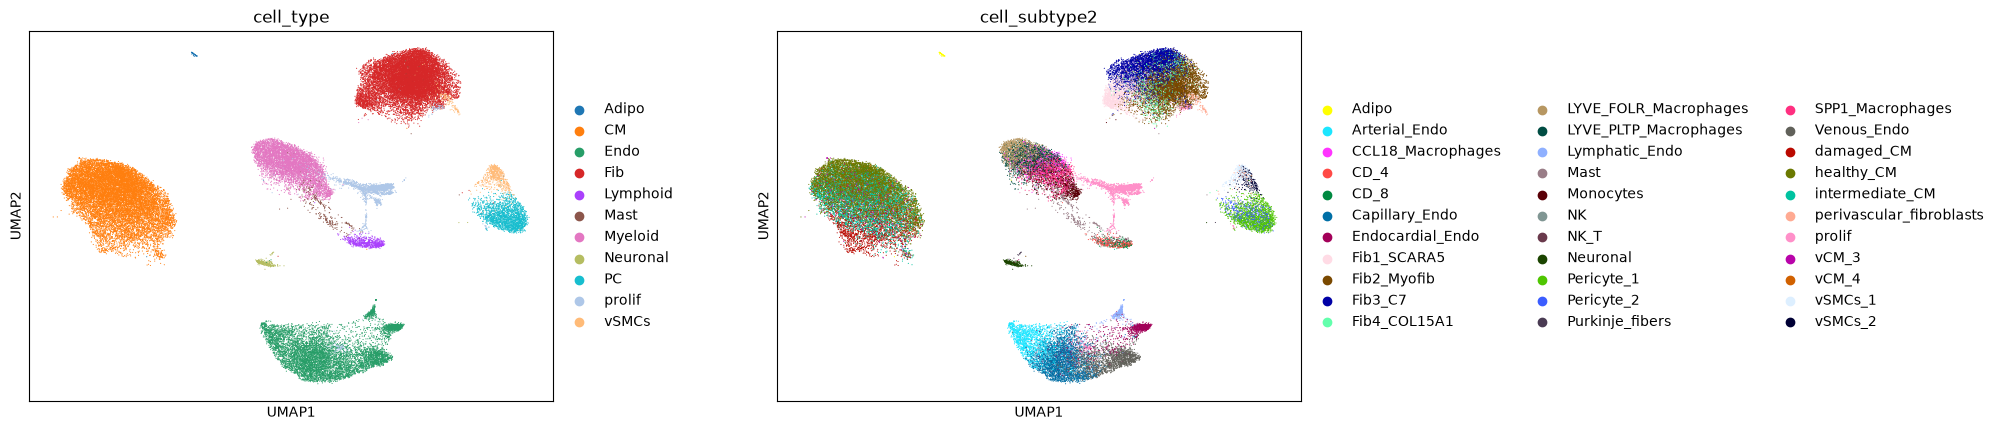

In [3]:
mudata['sc'].obsm['umap'] = mudata['sc'].obsm['X_umap_harmony']
sc.pl.umap(mudata['sc'], color=['cell_type', 'cell_subtype2'], wspace=0.3)


## 3. Co-localization

### Cell type proportions per spot

We deconvoluted cell subtypes in the Visium slices using [MOSCOT](https://moscot.readthedocs.io) (Klein et al., 2025), obtaining per-cell probabilities of being in each spot. `nichesphere.tl.get_spot_ct_props` sums these probabilities per cell type to give cell type proportion matrices per spot.

Below we show this for two example samples. The **sample** the cells or spots come from is indicated in the **patient_region_id** column in the obs slot of our snRNA-seq and Visium data: `mudata['sc'].obs.patient_region_id` and `mudata['visium'].obs.patient_region_id`

The full table for all 23 samples is available directly from Zenodo.


In [4]:
CTprops = pd.DataFrame()
for smpl in ['control_P1', 'GT_IZ_P9']:
    t = pd.read_csv(f'../../data/MIvisium/main_tutorial/cell_probs_{smpl}.csv', index_col=0)

    adata_sc = mudata['sc'][mudata['sc'].obs.patient_region_id == smpl]
    # Keep only cell types with more than 2 cells in this sample
    adata_sc = adata_sc[[
        c in adata_sc.obs.cell_subtype2.value_counts().index[
            adata_sc.obs.cell_subtype2.value_counts() > 2
        ] for c in adata_sc.obs.cell_subtype2
    ]]

    props = nichesphere.tl.get_spot_ct_props(
        spot_cell_props=t,
        sc_ct=adata_sc.obs.cell_subtype2
    )
    CTprops = pd.concat([CTprops, props])


Load the full cell type proportions table (all 23 samples) from Zenodo:

In [5]:
CTprops = pd.read_csv('../../data/MIvisium/main_tutorial/CTprops.csv', index_col=0)
## Subset as we just use 9 samples for this tutorial
CTprops=CTprops.loc[mudata['visium'].obs.index]
CTprops.head()


,Fib1_SCARA5,damaged_CM,Capillary_Endo,LYVE_FOLR_Macrophages,Fib3_C7,healthy_CM,Fib2_Myofib,Endocardial_Endo,Arterial_Endo,Neuronal,...,CCL18_Macrophages,perivascular_fibroblasts,CD_4,vSMCs_2,Lymphatic_Endo,NK,CD_8,Purkinje_fibers,Adipo,NK_T
AAACAAGTATCTCCCA-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.000000,0.0,0.0,0.000000,1.000000,0.0,0.0,1.249070e-32,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,0.0
AAACACCAATAACTGC-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,...,0.0,0.0,0.341564,0.0,0.0,0.0,0.0,0.0,NaN,0.0
AAACAGCTTTCAGAAG-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.000000,0.0,0.0,0.358745,0.282511,0.0,0.0,0.000000e+00,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,0.0
AAACAGGGTCTATATT-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.328716,0.0,0.0,0.000000,0.335562,0.0,0.0,0.000000e+00,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,0.0
AAACCGGGTAGGTACC-1-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0-0,0.0,0.000000,0.0,0.0,0.994955,0.005045,0.0,0.0,0.000000e+00,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,0.0


### Inspecting deconvolution results

We can check cell type proportions per sample with a clustermap or barplots, and visualize the dominant cell type per spot in a Visium slice.


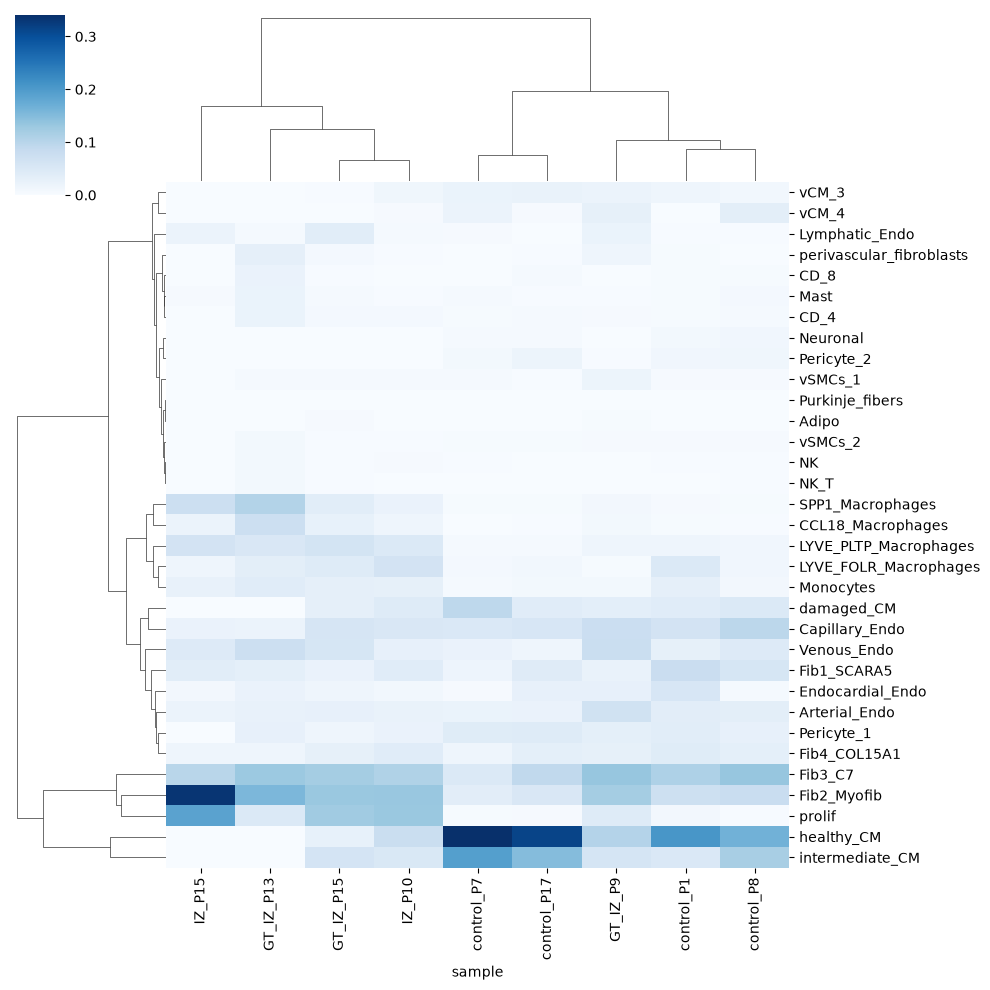

In [6]:
spotSamples = mudata['visium'].obs.patient_region_id

CTprops_sample = CTprops.loc[spotSamples.index].copy()
CTprops_sample['sample'] = spotSamples.values
sns.clustermap(
    CTprops_sample.groupby('sample').sum().T /
    CTprops_sample.groupby('sample').sum().sum(axis=1),
    cmap='Blues', method='ward'
)


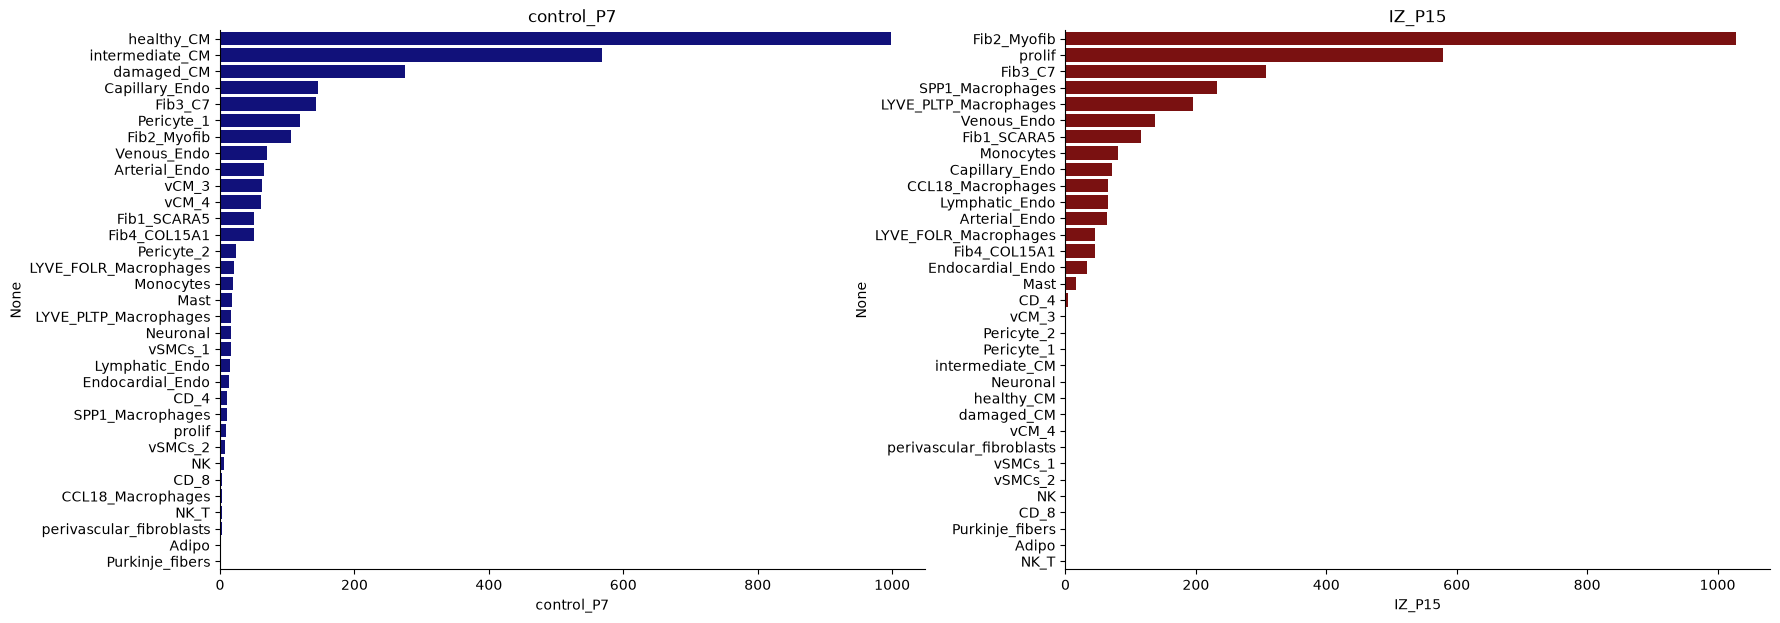

In [7]:
t1 = pd.DataFrame(CTprops[spotSamples == 'control_P7'].sum(), columns=['control_P7'])
t2 = pd.DataFrame(CTprops[spotSamples == 'IZ_P15'].sum(), columns=['IZ_P15'])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.set_style(rc={'axes.facecolor': 'white'})

sns.barplot(ax=axes[0], y=t1.sort_values('control_P7', ascending=False).index,
            x='control_P7', data=t1.sort_values('control_P7', ascending=False), color='darkblue')
axes[0].set_title('control_P7')

sns.barplot(ax=axes[1], y=t2.sort_values('IZ_P15', ascending=False).index,
            x='IZ_P15', data=t2.sort_values('IZ_P15', ascending=False), color='darkred')
axes[1].set_title('IZ_P15')
sns.despine()


We can also color each Visium spot by the cell type with the highest proportion using `nichesphere.coloc.spatialCTPlot`:

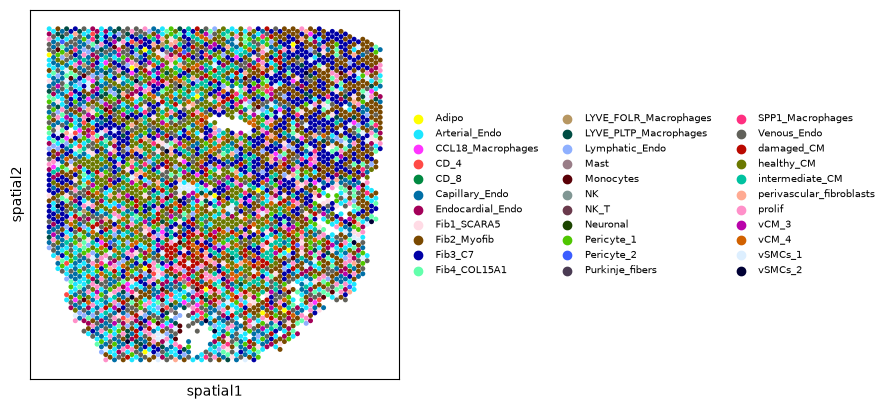

In [8]:
mudata['visium'].uns['spatial'] = mudata['visium'].obsm['X_spatial']

idPat = 'GT_IZ_P9'
nichesphere.coloc.spatialCTPlot(
    adata=mudata['visium'][mudata['visium'].obs.patient_region_id == idPat].copy(),
    CTprobs=CTprops.loc[spotSamples.index[spotSamples == idPat]],
    cell_types=mudata['sc'].obs.cell_subtype2,
    spot_size=0.015,
    legend_fontsize=7
)


### Co-localization probabilities

`nichesphere.coloc.getColocProbs` computes concatenated co-localization matrices (cell type × cell type) per sample based on the probabilities of each cell type per spot. If additional information on the number of cells per spot is available (eg: an estimated number of cells per spot by cell2location), spot weights can be added to the co-localization probabilities calculations via the `spotweights` parameter. 


In [9]:
CTcolocalizationP = nichesphere.coloc.getColocProbs(
    CTprobs=CTprops,
    spotSamples=mudata['visium'].obs.patient_region_id
)


`reshapeColoc` then pivots these into a cell type pair × sample matrix. Setting `complete=1` indicates that both directions of each pair (ct1–ct2 and ct2–ct1) are present in the data.

As a safety check, we sum the co-localization probabilities across all cell pairs per sample. They should sum up to 1 per sample.

*If co-localization probabilities do not sum up to 1, it might be worth checking if the given `CTprobs` are indeed cell type probabilities per spot (they should also sum up to 1 per spot).*

In [10]:
colocPerSample = nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
colocPerSample=colocPerSample.fillna(0)
colocPerSample.sum(axis=1)  # should be ~1.0 for every sample


GT_IZ_P13      1.0
GT_IZ_P15      1.0
GT_IZ_P9       1.0
IZ_P10         1.0
IZ_P15         1.0
control_P1     1.0
control_P17    1.0
control_P7     1.0
control_P8     1.0
dtype: float64

In [11]:
colocPerSample.head()


,Fib1_SCARA5-Fib1_SCARA5,Fib1_SCARA5-damaged_CM,Fib1_SCARA5-Capillary_Endo,Fib1_SCARA5-LYVE_FOLR_Macrophages,Fib1_SCARA5-Fib3_C7,Fib1_SCARA5-healthy_CM,Fib1_SCARA5-Fib2_Myofib,Fib1_SCARA5-Endocardial_Endo,Fib1_SCARA5-Arterial_Endo,Fib1_SCARA5-Neuronal,...,NK_T-CCL18_Macrophages,NK_T-perivascular_fibroblasts,NK_T-CD_4,NK_T-vSMCs_2,NK_T-Lymphatic_Endo,NK_T-NK,NK_T-CD_8,NK_T-Purkinje_fibers,NK_T-Adipo,NK_T-NK_T
GT_IZ_P13,0.018084,0.000000,0.000154,3.540328e-04,0.003069,0.000000e+00,0.002831,4.390572e-04,0.000276,0.0,...,8.345726e-05,1.007656e-05,0.00026,0.0,0.000000e+00,0.000000,3.963644e-04,0.0,0.0,0.004869
GT_IZ_P15,0.020017,0.000040,0.000107,1.413835e-05,0.000772,4.690843e-16,0.000702,6.130994e-09,0.000152,0.0,...,0.000000e+00,7.448928e-30,0.00000,0.0,3.143464e-46,0.000000,3.756373e-28,0.0,0.0,0.001477
GT_IZ_P9,0.019715,0.000200,0.000250,3.609267e-33,0.000643,3.859817e-04,0.000741,2.134773e-04,0.000366,0.0,...,0.000000e+00,0.000000e+00,0.00000,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.000000
IZ_P10,0.030229,0.000096,0.000610,3.347724e-04,0.002416,1.363541e-05,0.001721,1.966849e-04,0.000138,0.0,...,6.626314e-36,0.000000e+00,0.00000,0.0,0.000000e+00,0.000024,0.000000e+00,0.0,0.0,0.000857
IZ_P15,0.030351,0.000000,0.000027,1.859005e-04,0.001200,0.000000e+00,0.003112,7.228002e-05,0.000062,0.0,...,0.000000e+00,0.000000e+00,0.00000,0.0,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.000000


### Sample–condition mapping

Condition is encoded in sample name abbreviations: RZ = Remote zone, BZ = Border zone, FZ = Fibrotic zone, IZ = Ischemic zone. Everything else is myogenic (healthy).


In [12]:
sampleTypesDF = pd.DataFrame(colocPerSample.index, columns=['sample'])
sampleTypesDF['sampleType'] = 'myogenic'
for abbrev, label in [('RZ', 'remote'), ('BZ', 'border'), ('FZ', 'fibrotic'), ('IZ', 'ischemic')]:
    sampleTypesDF.loc[sampleTypesDF['sample'].str.contains(abbrev), 'sampleType'] = label
sampleTypesDF.head()


,sample,sampleType
0,GT_IZ_P13,ischemic
1,GT_IZ_P15,ischemic
2,GT_IZ_P9,ischemic
3,IZ_P10,ischemic
4,IZ_P15,ischemic


We also build the list of same-cell-type pairs (e.g. `CM-CM`), which will be excluded from differential testing:

In [13]:
cell_types = CTprops.columns
oneCTints = cell_types + '-' + cell_types


## 4. Differential co-localization

We test differential co-localization between **myogenic** and **ischemic** samples using Wilcoxon rank-sum tests (one test per cell type pair):

- **H₀:** The median difference in co-localization probability between myogenic and ischemic samples is zero.
- **H₁:** The median difference is non-zero.


In [14]:
myo_iscDF = nichesphere.coloc.diffColoc_test(
    coloc_pair_sample=colocPerSample,
    sampleTypes=sampleTypesDF,
    exp_condition='ischemic',
    ctrl_condition='myogenic'
)
myo_iscDF.head()


,pairs,statistic,p-value
pairs,,,
Fib1_SCARA5-Fib1_SCARA5,Fib1_SCARA5-Fib1_SCARA5,0.489898,0.624206
Fib1_SCARA5-damaged_CM,Fib1_SCARA5-damaged_CM,-2.44949,0.014306
Fib1_SCARA5-Capillary_Endo,Fib1_SCARA5-Capillary_Endo,-2.204541,0.027486
Fib1_SCARA5-LYVE_FOLR_Macrophages,Fib1_SCARA5-LYVE_FOLR_Macrophages,-0.489898,0.624206
Fib1_SCARA5-Fib3_C7,Fib1_SCARA5-Fib3_C7,-2.44949,0.014306


`nichesphere.tl.pval_filtered_HMdf` reshapes the test results into a cell type × cell type heatmap matrix, setting non-significant scores (p > `p`) to 0. We then remove proliferating cells (hard to interpret as a single cell type) and any cell types with no significant co-localization changes.


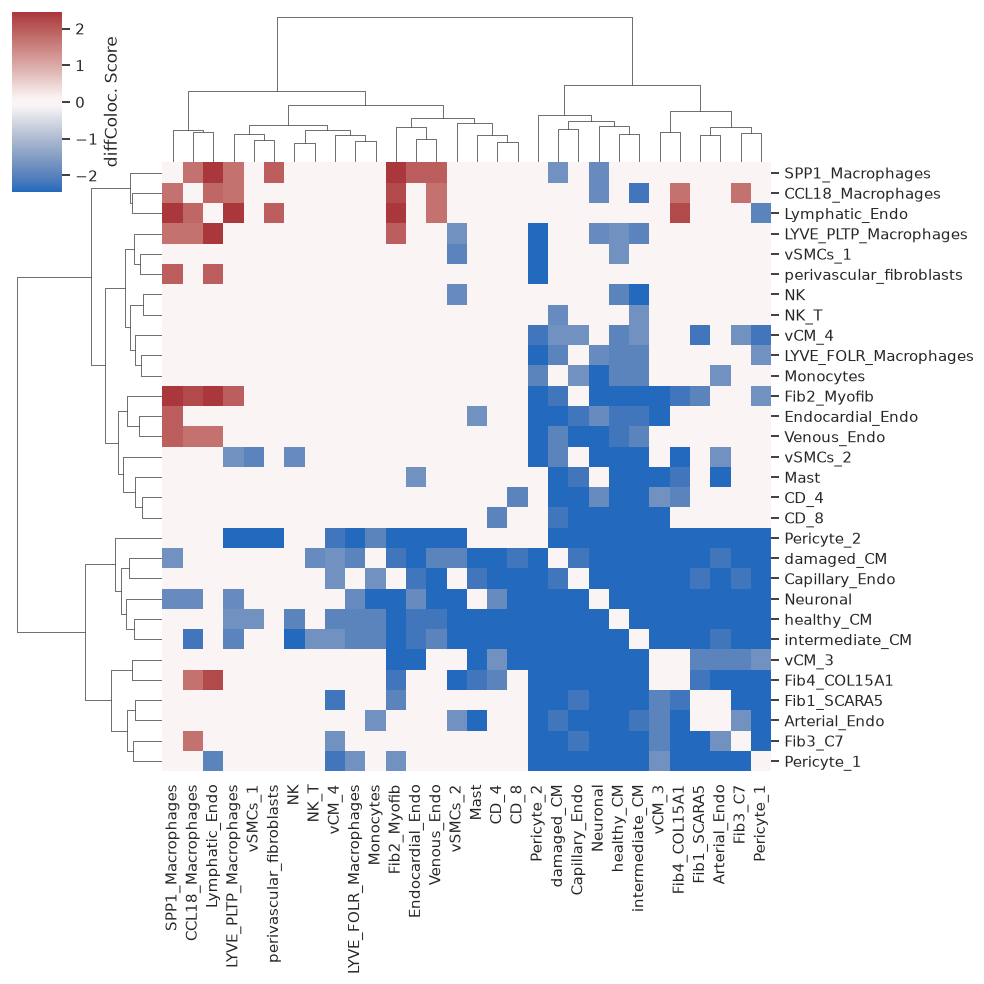

In [15]:
myo_isc_HM = nichesphere.tl.pval_filtered_HMdf(
    testDF=myo_iscDF,
    oneCTinteractions=oneCTints,
    p=0.1,
    cell_types=cell_types
)

# Remove proliferating cells and rows/columns with all-zero scores
myo_isc_HM = myo_isc_HM.loc[
    ~myo_isc_HM.columns.str.contains('prolif'),
    ~myo_isc_HM.index.str.contains('prolif')
]
myo_isc_HM = myo_isc_HM.loc[myo_isc_HM.sum() != 0, myo_isc_HM.sum() != 0]

sns.set(font_scale=1)
sns.clustermap(myo_isc_HM, cmap='vlag', center=0, method='ward',
               cbar_kws={'label': 'diffColoc. Score'})


## 5. Differential co-localization network and niche detection

### Adjacency matrix

We build an adjacency matrix from Euclidean distances between each cell type's differential co-localization profile. Cell types with no significant differential co-localization receive a weight of 0.


In [16]:
HMdist = pd.DataFrame(
    scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(myo_isc_HM)),
    columns=myo_isc_HM.columns, index=myo_isc_HM.index
)
HMsimm = 1 - HMdist / HMdist.max().max()
HMsimm[myo_isc_HM == 0] = 0


### Initial network

We first plot the network with all nodes in a single placeholder group to get a visual overview before community detection.

`colocNW` parameters:
- `nodeSize`: size of nodes by network statistic — `'betweeness'`, `'pagerank'`, or `None` (uniform)
- `alpha`: edge transparency (0–1)
- `edge_scale`: edge width multiplier


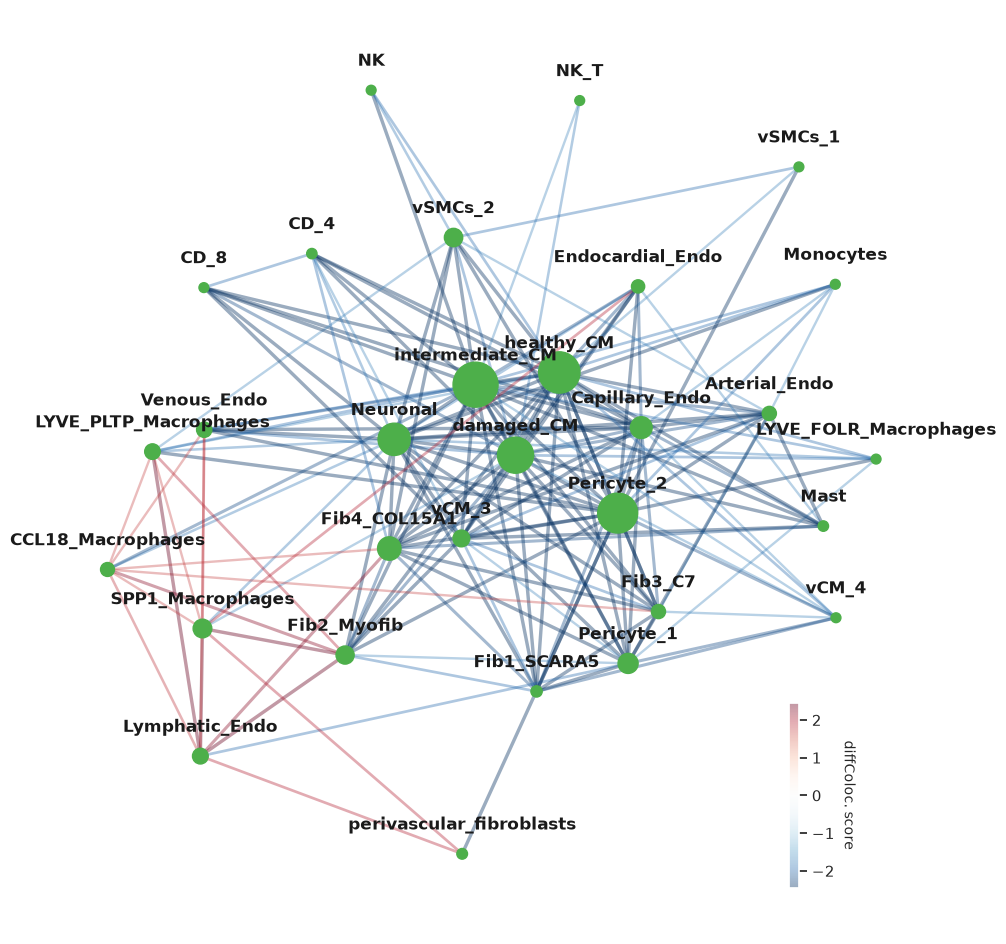

In [17]:
niches_dict = {'1_': list(myo_isc_HM.index)}
clist = ['#4daf4a']

plt.rcParams['axes.facecolor'] = 'None'
nichesphere.coloc.colocNW(
    x_diff=myo_isc_HM,
    adj=HMsimm,
    cell_group=niches_dict,
    clist=clist,
    nodeSize='betweeness',
    lab_spacing=9,
    alpha=0.4,
    fsize=(12, 12)
)


### Niche detection

We detect communities (niches) using Louvain clustering on the unsigned adjacency network, then use `CommunityLayout` to position nodes so that niches are spatially grouped. `CommunityLayout` is compatible with any NetworkX community detection function, specified via `community_algorithm` and `community_kwargs`.


In [18]:
gCol_unsigned = nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

cl = CommunityLayout(
    gCol_unsigned,
    community_compression=0.4,
    layout_algorithm=nx.spring_layout,
    layout_kwargs={"k": 75, "iterations": 1000},
    community_algorithm=nx.algorithms.community.louvain_communities,
    community_kwargs={"resolution": 1.1, "seed": 12, "weight": "weight"}
)

d = {i: list(v) for i, v in enumerate(cl.communities())}
print(pd.DataFrame.from_dict(d, orient='index').T.to_string(index=False))


Building meta-graph
Metagraph is a Graph with 4 nodes and 6 edges


100%|██████████| 4/4 [00:00<00:00, 412.34it/s]

           0                     1             2                        3
  Pericyte_1              Neuronal       vSMCs_2        CCL18_Macrophages
 Fib1_SCARA5                  Mast       vSMCs_1    LYVE_PLTP_Macrophages
     Fib3_C7                  NK_T     Monocytes              Fib2_Myofib
Fib4_COL15A1            damaged_CM            NK           Lymphatic_Endo
  Pericyte_2 LYVE_FOLR_Macrophages Arterial_Endo perivascular_fibroblasts
       vCM_4        Capillary_Endo    healthy_CM         SPP1_Macrophages
        None      Endocardial_Endo          None              Venous_Endo
        None       intermediate_CM          None                     None
        None                  CD_4          None                     None
        None                 vCM_3          None                     None
        None                  CD_8          None                     None


In [19]:
niche_names = ['1_Stromal', '2_Stressed_CM', '3_Healthy_CM', '4_Fibrotic']
niches_dict = dict(zip(niche_names, list(d.values())))

clist = ['#4daf4a', '#0072B5', '#BC3C29', '#ffff33']
niche_cols = pd.Series(clist, index=list(niches_dict.keys()))
niches_df = nichesphere.tl.cells_niche_colors(
    CTs=CTprops.columns, niche_colors=niche_cols, niche_dict=niches_dict
)
niches_df.head()


,cell,niche,color
cell,,,
Fib1_SCARA5,Fib1_SCARA5,1_Stromal,#4daf4a
damaged_CM,damaged_CM,2_Stressed_CM,#0072B5
Capillary_Endo,Capillary_Endo,2_Stressed_CM,#0072B5
LYVE_FOLR_Macrophages,LYVE_FOLR_Macrophages,2_Stressed_CM,#0072B5
Fib3_C7,Fib3_C7,1_Stromal,#4daf4a


### Final network plot

We pass the community-aware node positions via `pos` and set `layout=None`:

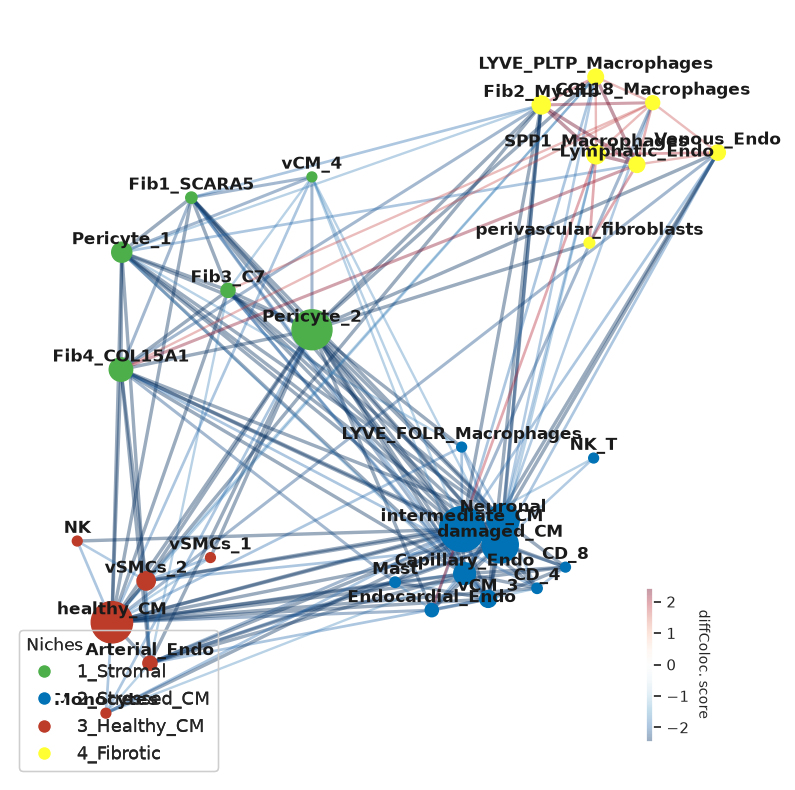

In [20]:
pos = cl.full_positions

plt.rcParams['axes.facecolor'] = 'None'
gCol = nichesphere.coloc.colocNW(
    x_diff=myo_isc_HM,
    adj=HMsimm,
    cell_group=niches_dict,
    clist=clist,
    nodeSize='betweeness',
    layout=None,
    lab_spacing=0.05,
    thr=1,
    alpha=0.4,
    fsize=(10, 10),
    pos=pos,
    edge_scale=1,
    legend_ax=[0.7, 0.05, 0.15, 0.2]
)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=clist[i],
               lw=4, label=list(niches_dict.keys())[i], ms=10)
    for i in range(len(niches_dict))
]
plt.gca().add_artist(
    plt.legend(handles=legend_elements, loc='lower left', fontsize=13,
               title='Niches', alignment='left')
)
# plt.savefig('diffColocNW.pdf')


We save the network and node positions for reuse in the communication section:

In [21]:
#nx.write_graphml_lxml(gCol, 'data/colocNW_MIvisium_louvain.graphml')
#np.save('data/colocNW_pos.npy', pos)


We also save the niche–cell type correspondence and co-localization filter tables, needed for differential communication:

In [22]:
#niches_df.to_csv('data/niches_df_MIvisium_louvain.csv')

pairCatDFdir = nichesphere.tl.get_pairCatDFdir(niches_df)
#pairCatDFdir.to_csv('data/pairCatDFdir_MIvisium_louvain.csv')

# Flag differentially co-localized cell pairs (filter=1 → will be tested in comm analysis)
pairCatDF_filter = [
    (pairCatDFdir.cell_pairs.str.split('->')[i][0] in HMsimm.index) and
    (pairCatDFdir.cell_pairs.str.split('->')[i][1] in HMsimm.index)
    for i in pairCatDFdir.index
]
pairCatDFdir_filt = pairCatDFdir[pairCatDF_filter]
oneCTints_filt = oneCTints[[i.split('-')[0] in HMsimm.index for i in oneCTints]]

colocFilt = nichesphere.tl.getColocFilter(
    pairCatDF=pairCatDFdir_filt,
    adj=HMsimm,
    oneCTints=oneCTints_filt.str.replace('-', '->')
)
#colocFilt.to_csv('data/colocFilt_MIvisium_louvain.csv')
colocFilt.head()


,filter
cell_pairs,
Fib1_SCARA5->Fib1_SCARA5,1.0
Fib1_SCARA5->damaged_CM,1.0
Fib1_SCARA5->Capillary_Endo,1.0
Fib1_SCARA5->LYVE_FOLR_Macrophages,0.0
Fib1_SCARA5->Fib3_C7,1.0


We also assign niche/community properties to the network object for downstream use:

In [23]:
nichesphere.tl.assign_properties(
    gCol,
    communities=cl.communities(),
    colors=clist,
    pos=pos,
    simmilarity_weights=True,
    node_coord_sf=100,
    g_unsigned=gCol_unsigned
)


### Interactive network

The `gravis` library enables an interactive D3-based network visualization where node sizes, edge widths, and label sizes can be adjusted in the browser. One can also move the nodes around to avoid overlaps.

> **Note:** gravis may require downgrading setuptools: `pip install --force-reinstall -U "setuptools<82.0.0"`


In [24]:
import gravis as gv
gv.d3(gCol, edge_size_data_source='weight_abs', zoom_factor=0.35, layout_algorithm_active=False)


## 6. Network statistics

`nichesphere.tl.compute_network_stats` computes betweenness centrality, PageRank, and signed degree centrality (split into positive and negative edges) for the co-localization network. `plot_top_stats` visualises the top nodes for each metric.


In [25]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()


,betweenness,pagerank,degree_positive,degree_negative
Fib1_SCARA5,-24.303800,-1.706905,0.000000,0.413793
damaged_CM,-29.868265,-2.560918,0.000000,0.758621
Capillary_Endo,-28.048485,-2.250336,0.000000,0.620690
LYVE_FOLR_Macrophages,0.000000,-0.726972,0.000000,0.206897
Fib3_C7,-24.028574,-0.499136,0.034483,0.413793


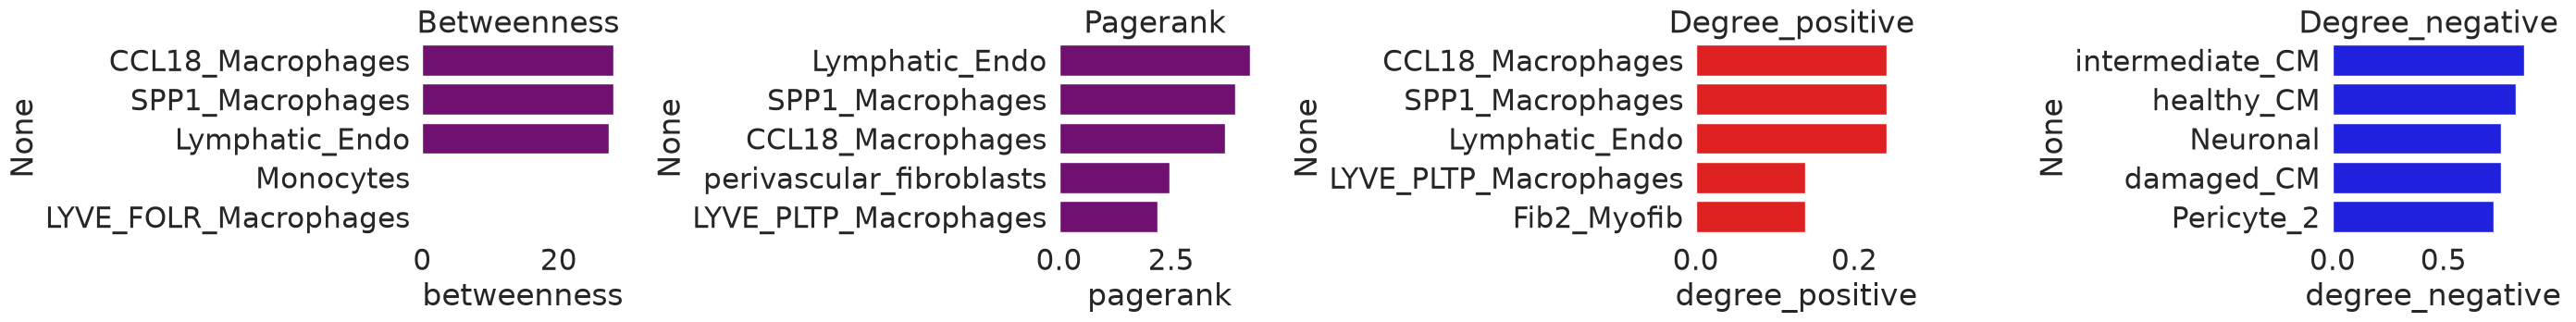

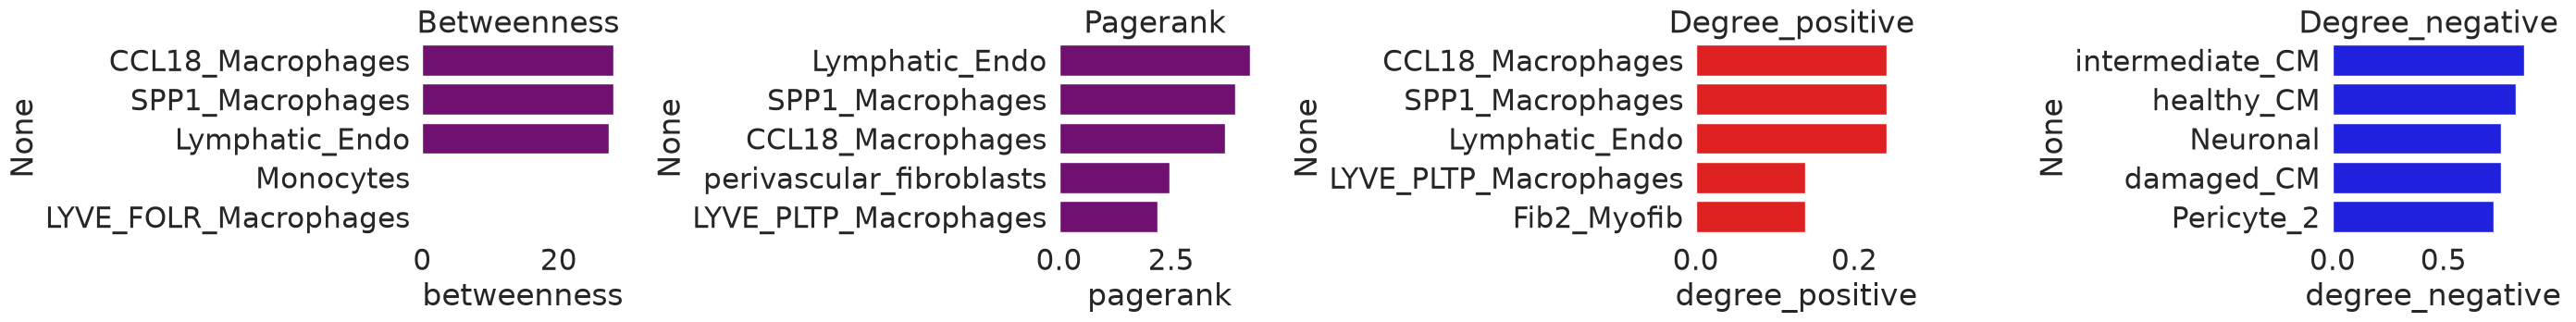

In [26]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = 'None'
nichesphere.tl.plot_top_stats(nw_stats, top_n=5)
# plt.savefig('diffColocNW_stats.pdf', bbox_inches='tight')


## 7. Niche statistics

The `nichesphere.niche_stats` module provides tools to assess the internal cohesion of each niche relative to its cross-niche connections, using the signed edge weight distribution.

`community_edge_stats_df` returns a summary table of positive/negative edge counts and weights per niche:


In [27]:
vc_map_named = {node: niche for niche, members in niches_dict.items() for node in members}

edge_stats = nichesphere.niche_stats.community_edge_stats_df(gCol, vc_map_named)
edge_stats


,internal_pos_count,internal_pos_weight,internal_neg_count,internal_neg_weight,external_pos_count,external_pos_weight,external_neg_count,external_neg_weight
community,,,,,,,,
1_Stromal,0,0.000000,14,32.578214,3,5.633826,54,122.719436
2_Stressed_CM,0,0.000000,36,80.833162,1,1.959592,69,155.175175
3_Healthy_CM,0,0.000000,9,17.758801,0,0.000000,41,93.570508
4_Fibrotic,15,30.251198,0,0.000000,4,7.593418,26,55.480943


`plot_internal_external_boxplots` visualises the signed internal vs external edge weight distributions per niche. Niches where internal weights are higher than external weights are more cohesively co-localised internally than across niches.


<Axes: title={'center': 'Internal vs external edge weight distributions by niche'}, xlabel='niche', ylabel='edge weight'>

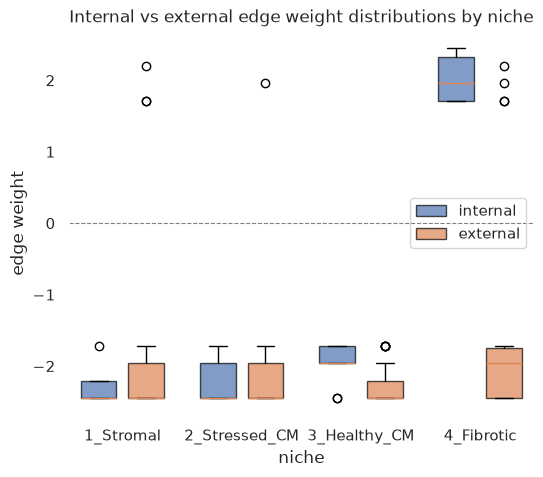

In [28]:
sns.set(font_scale=1)
plt.rcParams['axes.facecolor'] = 'None'
nichesphere.niche_stats.plot_internal_external_boxplots(gCol, vc_map_named)
# plt.savefig('niche_internal_external_weights.pdf', bbox_inches='tight')


A Wilcoxon rank-sum test can confirm whether internal and external weight distributions are significantly different per niche:

In [29]:
signed = nichesphere.niche_stats.community_signed_weight_distributions(gCol, vc_map_named)
communities = list(signed.keys())

pairwise_stats = nichesphere.niche_stats.pairwise_ranksums_int_ext(
    data_int=[signed[c]['internal'] for c in communities],
    data_ext=[signed[c]['external'] for c in communities],
    communities=communities
)
pairwise_stats


,niche,statistic,p_value,p_value_corrected
0,1_Stromal,-0.498588,0.618069,0.824093
1,2_Stressed_CM,-0.026684,0.978711,0.978711
2,3_Healthy_CM,2.487302,0.012872,0.025743
3,4_Fibrotic,4.851550,0.000001,0.000005


## 8. Niche visualization in Visium slices

`nichesphere.coloc.spatialNichePlot` colors each spot by the niche of the cell type with the highest proportion.


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

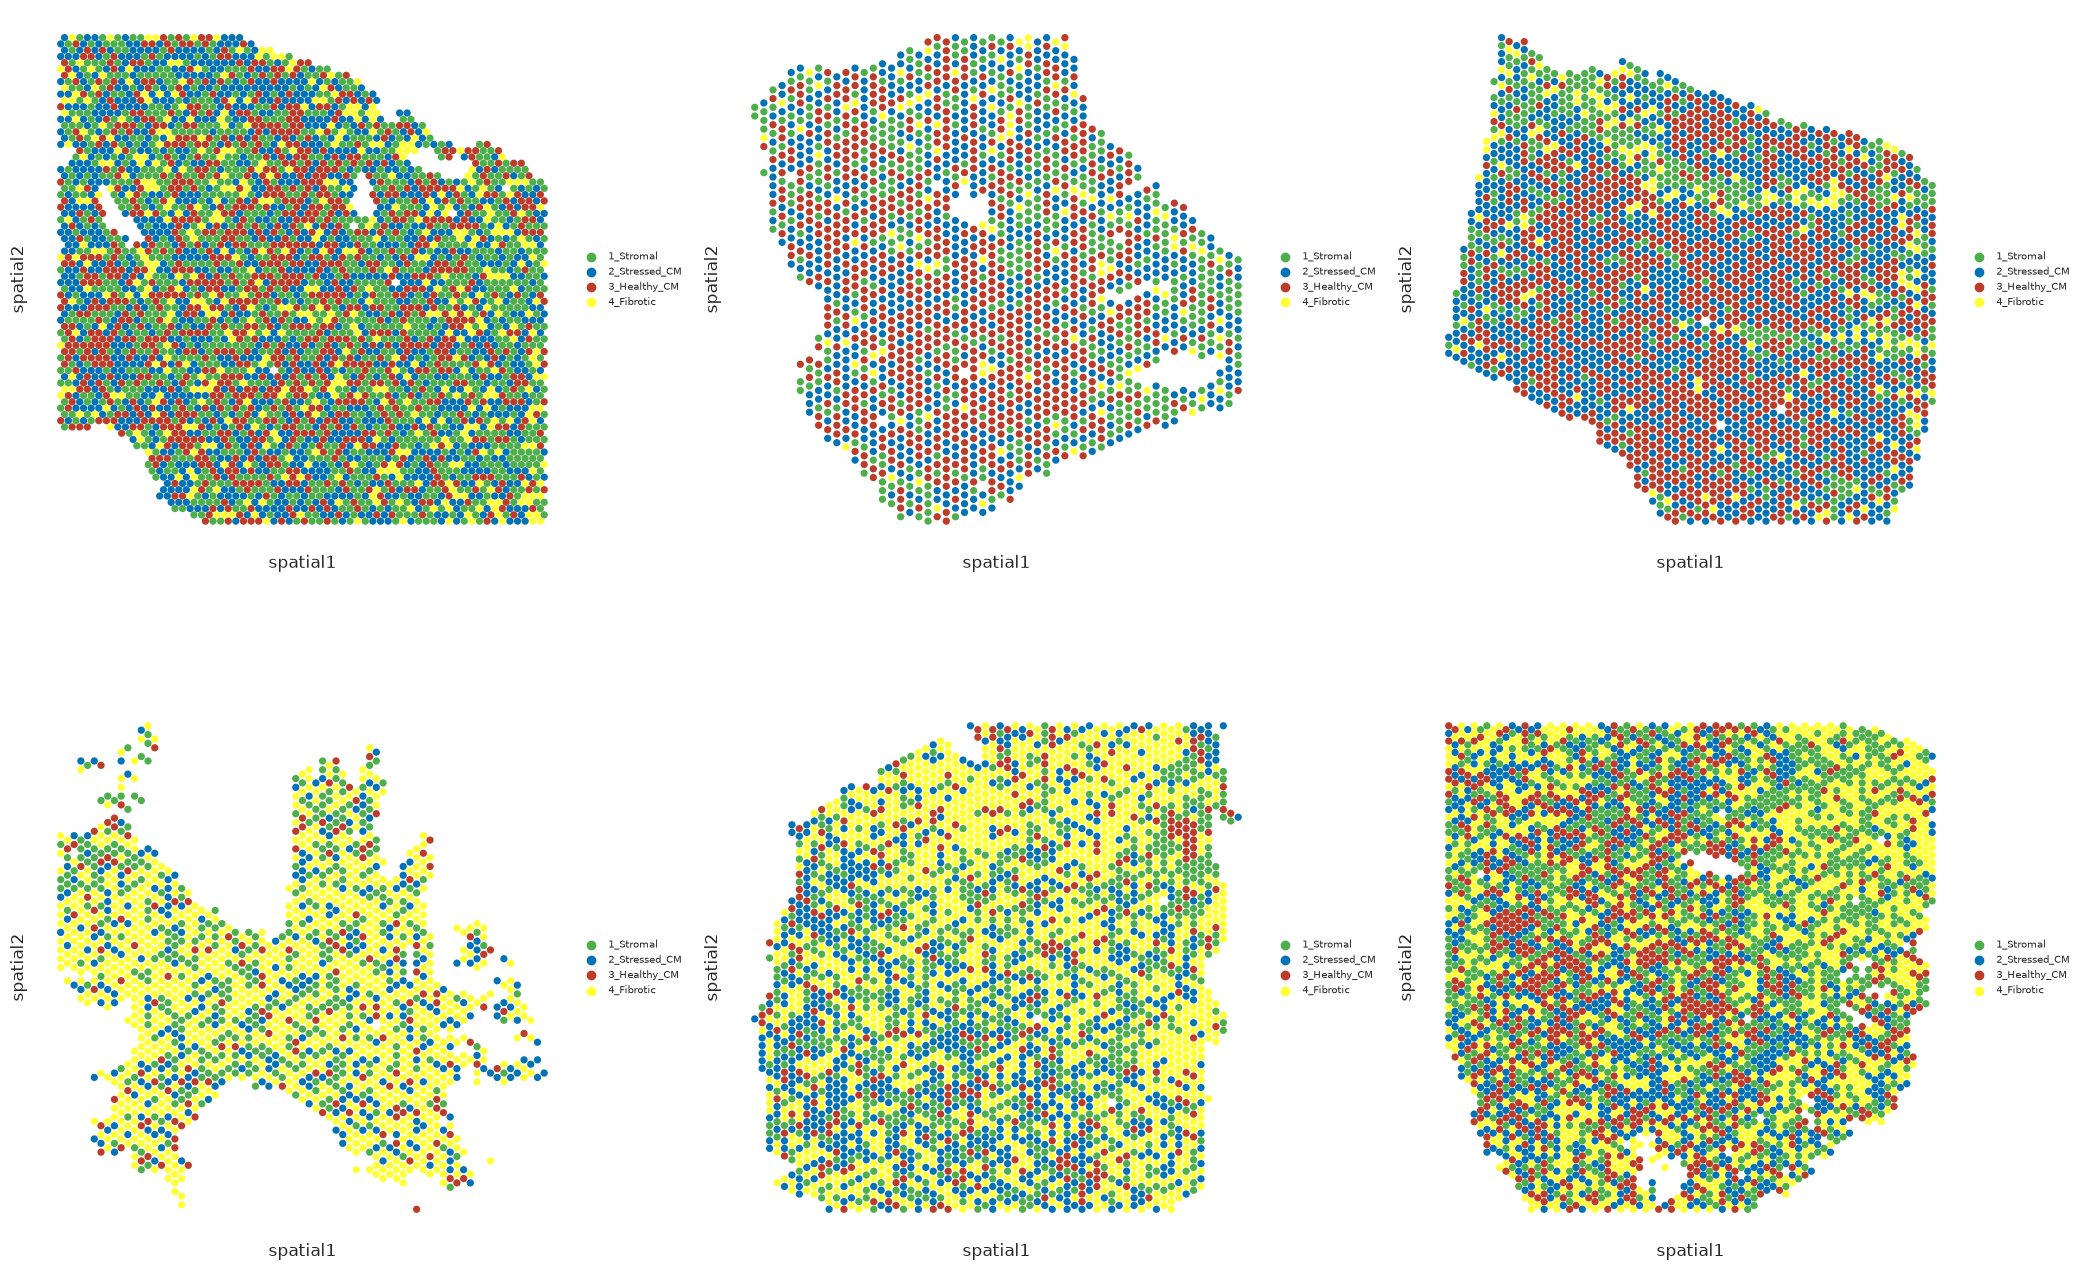

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(21, 14))
plt.close(fig)

for idu, smpl in enumerate(sampleTypesDF['sample'][sampleTypesDF['sampleType'] == 'myogenic'][:3]):
    nichesphere.coloc.spatialNichePlot(
        adata=mudata['visium'][mudata['visium'].obs.patient_region_id == smpl].copy(),
        CTprobs=CTprops.loc[spotSamples.index[spotSamples == smpl]],
        niche_dict=niches_dict,
        spot_size=0.015,
        niche_colors=niche_cols,
        legend_fontsize=7,
        #save_name=f'_{smpl}.pdf',
        ax=axes[0][idu]
    )

for idu, smpl in enumerate(sampleTypesDF['sample'][sampleTypesDF['sampleType'] == 'ischemic'][:3]):
    nichesphere.coloc.spatialNichePlot(
        adata=mudata['visium'][mudata['visium'].obs.patient_region_id == smpl].copy(),
        CTprobs=CTprops.loc[spotSamples.index[spotSamples == smpl]],
        niche_dict=niches_dict,
        spot_size=0.015,
        niche_colors=niche_cols,
        legend_fontsize=7,
        #save_name=f'_{smpl}.pdf',
        ax=axes[1][idu]
    )

fig.tight_layout()
fig


## 9. Communication data

To compute localized differential communication, we need per-condition LR interaction scores. We derive these by running [LIANA](https://github.com/saezlab/liana-py) on the scRNA-seq data per condition, then converting the results to pyCrossTalkeR format for the differential analysis.

### Prepare scRNA-seq data for LIANA

LIANA requires raw counts. The `mudata['sc']` object contains the processed scRNA-seq data; we build a lightweight raw-count AnnData from its `counts` layer, sharing `obs` and `var` without copying the full object.


In [31]:
adata_sc_raw=sc.read_h5ad('../../data/MIvisium/main_tutorial/snRNAseq_cellsWithSubtype_sampleType.h5ad')

In [32]:
## Subset for the samples we use
adata_sc_raw=adata_sc_raw[mudata['sc'].obs.index]

In [33]:
import anndata as ad
import liana as li
import os
from pycrosstalker import tools as cttl

adata_sc_raw.raw = adata_sc_raw


### Run LIANA per condition

We run LIANA's CellPhoneDB method on the scRNA-seq data of each condition separately, using `cell_subtype2` as the grouping variable. We use the human consensus resource (`humanconsensus`); adjust `resource_name` if your data is from another species.

> **Note:** This step can take several minutes per condition. The precomputed tables are available on Zenodo if you prefer to skip it (see below).


In [34]:
adata_sc_raw.uns['liana'] = {}

conditions = sampleTypesDF['sampleType'].unique()
for cond in conditions:
    samples_in_cond = sampleTypesDF.loc[sampleTypesDF['sampleType'] == cond, 'sample']
    adata_cond = adata_sc_raw[adata_sc_raw.obs['patient_region_id'].isin(samples_in_cond)]

    lr = li.method.cellphonedb(
        adata_cond,
        groupby='cell_subtype2',
        expr_prop=0.1,
        verbose=True,
        resource_name='consensus',
        inplace=False
    )
    adata_sc_raw.uns['liana'][cond] = lr


Using resource `consensus`.
Using `.raw`!
Converting to sparse csr matrix!
8587 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
0.29 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 16776 samples and 1245 features


100%|██████████| 1000/1000 [01:17<00:00, 12.91it/s]
Using resource `consensus`.
Using `.raw`!
Converting to sparse csr matrix!
2340 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
0.17 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 31771 samples and 1504 features


100%|██████████| 1000/1000 [03:50<00:00,  4.34it/s]


### Convert to pyCrossTalkeR and run differential analysis

`cttl.utils.from_liana` converts the LIANA output into pyCrossTalkeR format. `cttl.analise_LR` then runs the differential LR analysis between conditions, producing per-condition communication tables and a comparison table (`ischemic_x_myogenic`).


In [35]:
adata_sc_raw = cttl.utils.from_liana(adata_sc_raw)
adata_sc_raw.uns['pycrosstalker']['details'] = {'filename': 'MIvisium'}

output = 'results/output_ctkr/MIvisium/'
os.makedirs(output, exist_ok=True)

adata_sc_raw = cttl.analise_LR(
    adata_sc_raw,
    out_path=output,
    comparison=[('ischemic', 'myogenic')]
)


Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done
Generating h5ad file with Analysed Results


### Retrieve communication tables

We retrieve the per-condition LR tables from the pyCrossTalkeR output. `nichesphere.tl.processCTKRoutput` strips the `|L`, `|R`, and `|TF` suffixes that CrossTalkeR appends to gene names, which can otherwise conflict with downstream matching against the ligand database.

In [36]:
crossTalker_myoComm = adata_sc_raw.uns['pycrosstalker']['path']['myogenic']
crossTalker_iscComm = adata_sc_raw.uns['pycrosstalker']['path']['ischemic']

crossTalker_myoComm = nichesphere.tl.processCTKRoutput(crossTalker_myoComm)
crossTalker_iscComm = nichesphere.tl.processCTKRoutput(crossTalker_iscComm)


In [37]:
# Restrict to cell type pairs present in the co-localization network.
# pairCatDFdir only contains pairs that passed the differential co-localization
# filter; pairs absent from it (e.g. cell types removed during preprocessing)
# would cause a KeyError in lr_ctPairScores_perCat_dir.
valid_pairs = set(pairCatDFdir['cell_pairs'])
crossTalker_myoComm = crossTalker_myoComm[
    (crossTalker_myoComm['source'] + '->' + crossTalker_myoComm['target']).isin(valid_pairs)
]
crossTalker_iscComm = crossTalker_iscComm[
    (crossTalker_iscComm['source'] + '->' + crossTalker_iscComm['target']).isin(valid_pairs)
]

crossTalker_myoComm.head()

,source,target,type_gene_A,type_gene_B,gene_A,gene_B,MeanLR,cellpair,ligpair,recpair,allpair,LRScore
273495,intermediate_CM,healthy_CM,Ligand,Receptor,CALM1,RYR2,147.945694,intermediate_CM@healthy_CM,intermediate_CM/CALM1|L,healthy_CM/RYR2|R,intermediate_CM/CALM1@healthy_CM/RYR2,147.945694
264705,Endocardial_Endo,healthy_CM,Ligand,Receptor,CALM1,RYR2,147.889618,Endocardial_Endo@healthy_CM,Endocardial_Endo/CALM1|L,healthy_CM/RYR2|R,Endocardial_Endo/CALM1@healthy_CM/RYR2,147.889618
272920,healthy_CM,healthy_CM,Ligand,Receptor,CALM1,RYR2,147.882706,healthy_CM@healthy_CM,healthy_CM/CALM1|L,healthy_CM/RYR2|R,healthy_CM/CALM1@healthy_CM/RYR2,147.882706
275547,vCM_4,healthy_CM,Ligand,Receptor,CALM1,RYR2,147.870972,vCM_4@healthy_CM,vCM_4/CALM1|L,healthy_CM/RYR2|R,vCM_4/CALM1@healthy_CM/RYR2,147.870972
288072,intermediate_CM,intermediate_CM,Ligand,Receptor,CALM1,RYR2,147.856003,intermediate_CM@intermediate_CM,intermediate_CM/CALM1|L,intermediate_CM/RYR2|R,intermediate_CM/CALM1@intermediate_CM/RYR2,147.856003


### Ligand-process database

We use the NicheSphere database, which classifies ligands according to ECM-related and immune recruitment processes. It is available in the [NicheSphere GitHub repository](https://github.com/CostaLab/NicheSphere/tree/main/db).


In [38]:
import nichesphere.database as db


In [39]:
# Load database
allDBs = nichesphere.load_DB()


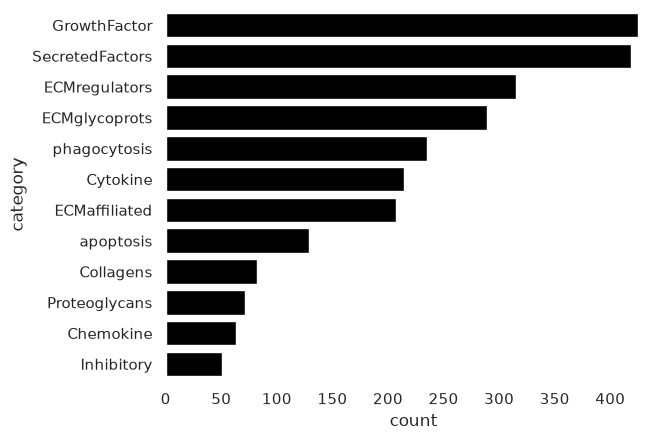

In [40]:
sns.barplot(x=allDBs.category.value_counts(), y=allDBs.category.value_counts().index,
            data=pd.DataFrame(allDBs.category.value_counts()), color='black')
sns.despine()


`lr_ctPairScores_perCat_dir` separates communication scores by biological process, computing the mean LR score per cell type pair per process category. `equalizeScoresTables` assigns 0 to interactions absent in one condition so both are directly comparable.


In [41]:
myoCTpairScores = nichesphere.comm.lr_ctPairScores_perCat_dir(
    ccommTable=crossTalker_myoComm,
    db=allDBs, dbCatCol='category', dbMatchCol='Ligand',
    ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR',
    oneCTinteractions=oneCTints.str.replace('-', '@'),
    condition='myogenic',
    pairCatDF=pairCatDFdir
)

iscCTpairScores = nichesphere.comm.lr_ctPairScores_perCat_dir(
    ccommTable=crossTalker_iscComm,
    db=allDBs, dbCatCol='category', dbMatchCol='Ligand',
    ccommMatchCol='gene_A', ccommLRscoresCol='MeanLR',
    oneCTinteractions=oneCTints.str.replace('-', '@'),
    condition='ischemic',
    pairCatDF=pairCatDFdir
)

myoCTpairScores, iscCTpairScores = nichesphere.comm.equalizeScoresTables(
    ctrlTbl=myoCTpairScores, expTbl=iscCTpairScores,
    ctrlCondition='myogenic', expCondition='ischemic'
)
myoCTpairScores.head()


,cell_pairs,niche_pairs,LRscores,LRcat,condition
allpair,,,,,
Adipo/COL10A1@Pericyte_2/ITGA1_ITGB1,Adipo->Pericyte_2,1_Stromal->1_Stromal,0.624593,Collagens,myogenic
Adipo/COL10A1@vCM_4/ITGA2_ITGB1,Adipo->vCM_4,1_Stromal->1_Stromal,0.296620,Collagens,myogenic
Adipo/COL14A1@CCL18_Macrophages/CD44,Adipo->CCL18_Macrophages,1_Stromal->4_Fibrotic,0.907862,Collagens,myogenic
Adipo/COL14A1@Endocardial_Endo/ITGA2_ITGB1,Adipo->Endocardial_Endo,1_Stromal->2_Stressed_CM,0.364431,Collagens,myogenic
Adipo/COL14A1@LYVE_FOLR_Macrophages/CD44,Adipo->LYVE_FOLR_Macrophages,1_Stromal->2_Stressed_CM,0.882113,Collagens,myogenic


## 10. Localized process-based differential communication

### Filter by differential co-localization

We restrict communication testing to cell type pairs with significant differential co-localization (`filter=1` in `colocFilt`):


In [42]:
#colocFilt = pd.read_csv('data/colocFilt_MIvisium_louvain.csv', index_col=0)
sig_pairs = colocFilt.index[colocFilt['filter'] == 1]

myoCTpairScores = myoCTpairScores[[i in sig_pairs for i in myoCTpairScores.cell_pairs]]
iscCTpairScores = iscCTpairScores[[i in sig_pairs for i in iscCTpairScores.cell_pairs]]


### Differential communication per niche pair

`diffCcommStats` tests for differential communication per process using Wilcoxon rank-sum tests. Setting `cellCatCol='niche_pairs'` aggregates at the niche level for a high-level view:


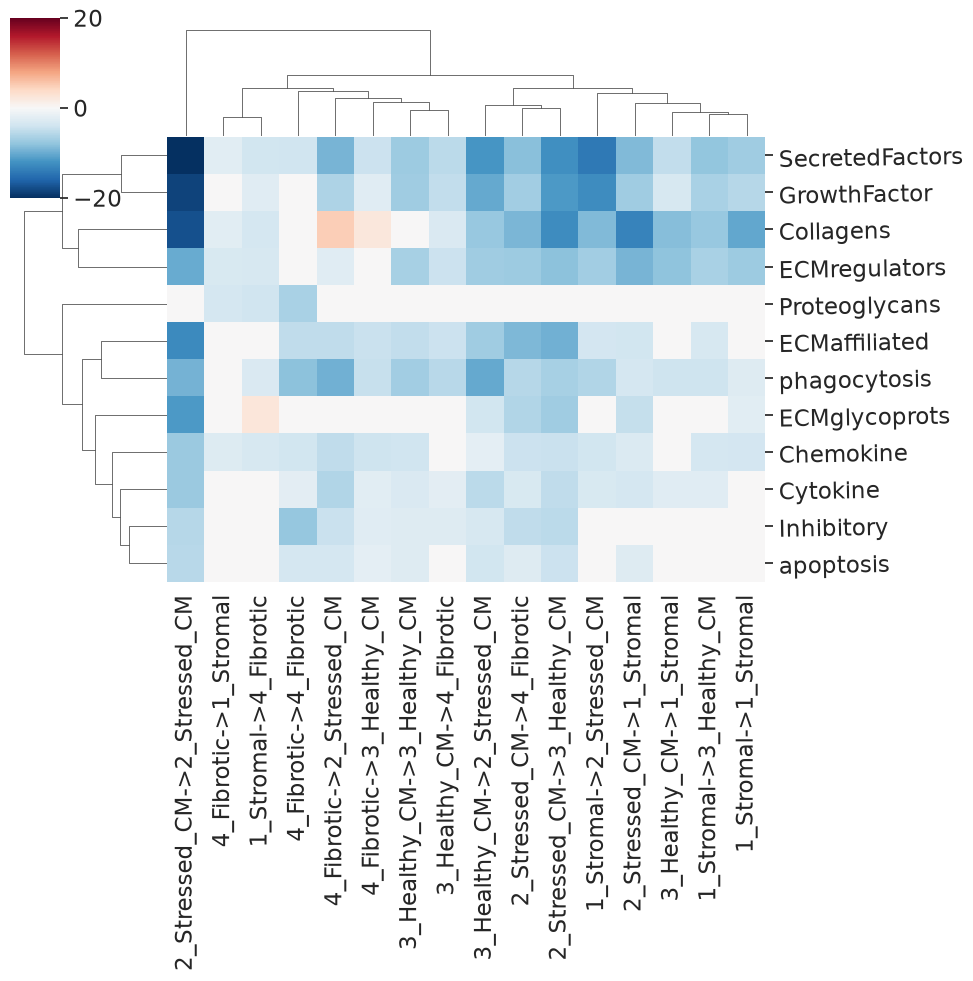

In [43]:
diffComm_niches = nichesphere.comm.diffCcommStats(
    c1CTpairScores_byCat=iscCTpairScores,
    c2CTpairScores_byCat=myoCTpairScores,
    cellCatCol='niche_pairs'
)

hm_df, cm = nichesphere.comm.plotDiffCcommStatsHM(
    diffCommTable=diffComm_niches, min_pval=0.05, vmin=-20, vmax=20
)


### Differential communication per cell type pair

We repeat the test with `cellCatCol='cell_pairs'` to get cell-type-level resolution, needed to build process-specific communication networks:


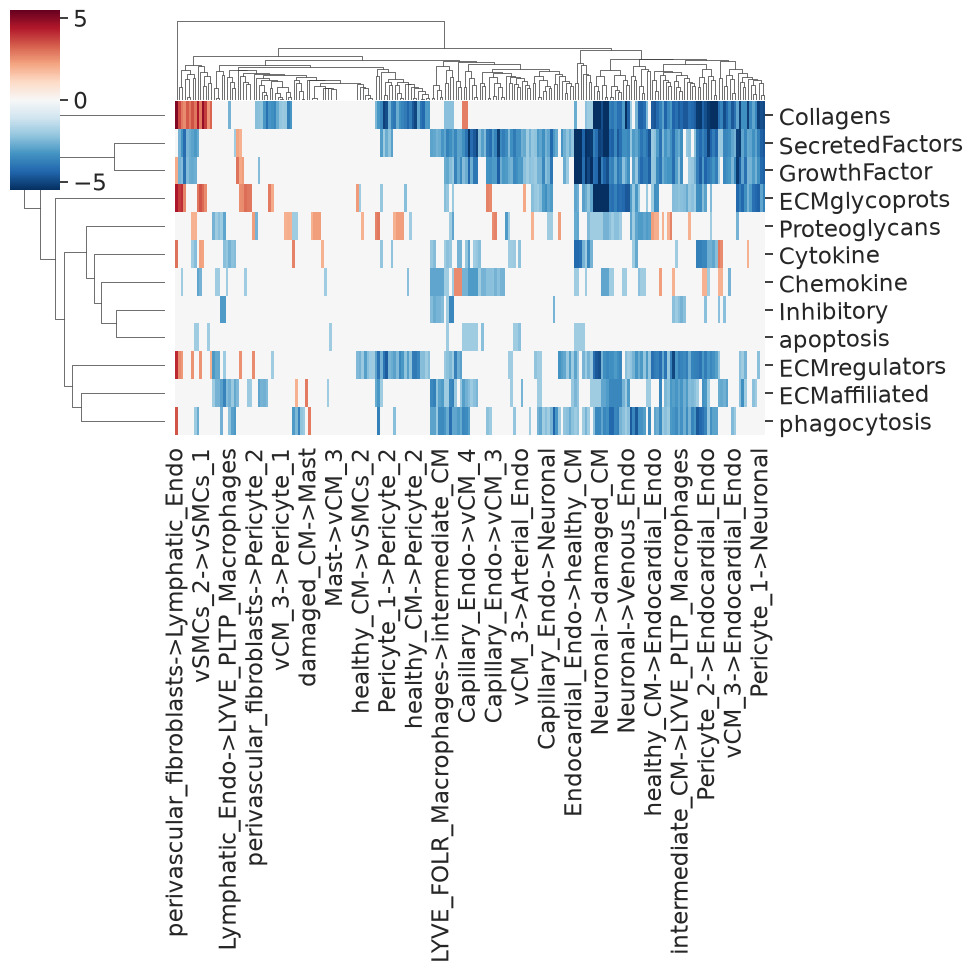

In [44]:
diffComm_ctpairs = nichesphere.comm.diffCcommStats(
    c1CTpairScores_byCat=iscCTpairScores,
    c2CTpairScores_byCat=myoCTpairScores,
    cellCatCol='cell_pairs'
)

x_myoIsc_dir, _ = nichesphere.comm.plotDiffCcommStatsHM(
    diffCommTable=diffComm_ctpairs, min_pval=0.05, vmin=-5.5, vmax=5.5
)


## 11. Localized differential communication networks

`getDiffComm` extracts differential communication scores for a specific process, then `catNW` overlays these scores as edge weights on the co-localization network layout. We reload the saved network and node positions:


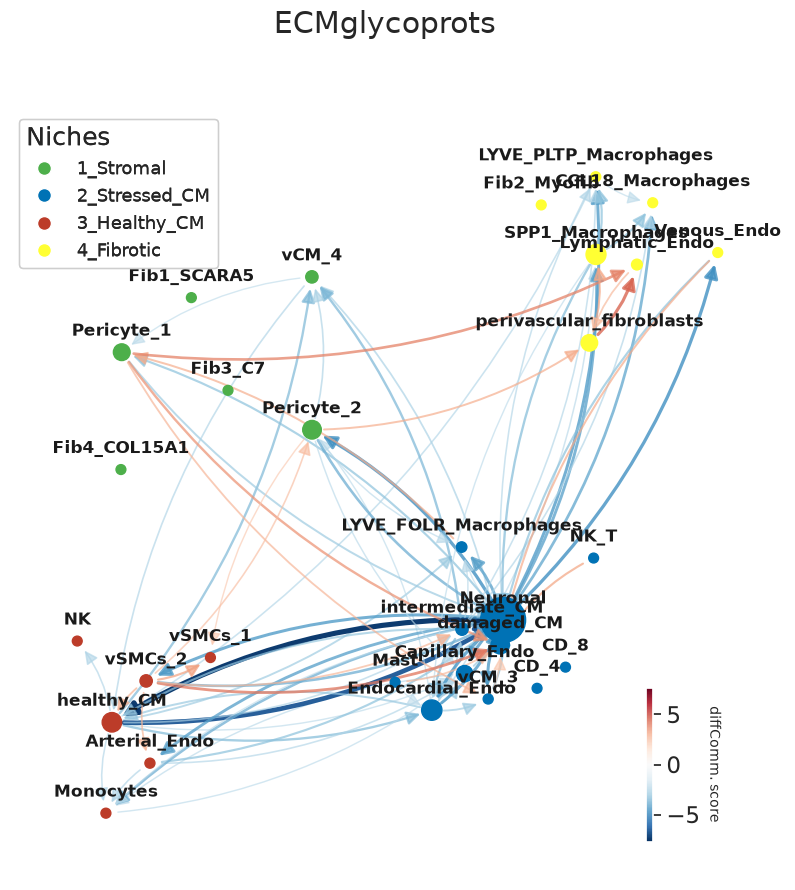

In [45]:
cat = 'ECMglycoprots'

x_chem = nichesphere.comm.getDiffComm(
    diffCommTbl=x_myoIsc_dir,
    pairCatDF=pairCatDFdir,
    ncells=33,
    cat=cat
)

plt.rcParams['axes.facecolor'] = 'None'
G = nichesphere.comm.catNW(
    x_chem=x_chem,
    colocNW=gCol,
    cell_group=niches_dict,
    plot_title=cat,
    clist=clist,
    nodeSize='betweeness',
    layout=None,
    #thr=5.5,
    fsize=(10, 10),
    #alpha=0.4,
    edge_scale=0.5,
    pos=pos,
    lab_spacing=0.05
)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=clist[i],
               lw=4, label=list(niches_dict.keys())[i], ms=10)
    for i in range(len(niches_dict))
]
plt.gca().add_artist(
    plt.legend(handles=legend_elements, loc='upper left', fontsize=13,
               title='Niches', alignment='left')
)
# plt.savefig(f'{cat}_diffCommNW.pdf')


Network statistics for the communication network (note: `G` here is a directed graph, so we use in/out-degree):

In [46]:
comm_stats = nichesphere.tl.compute_network_stats(G)
comm_stats.head()


,betweenness,pagerank,degree_positive,degree_negative
Fib1_SCARA5,0.000000,1.244569,0.000000,0.000000
damaged_CM,-24.834053,2.135863,0.206897,0.103448
Capillary_Endo,-27.801873,-1.975055,0.000000,0.310345
LYVE_FOLR_Macrophages,0.000000,-0.594277,0.034483,0.172414
Fib3_C7,0.000000,1.244569,0.000000,0.000000


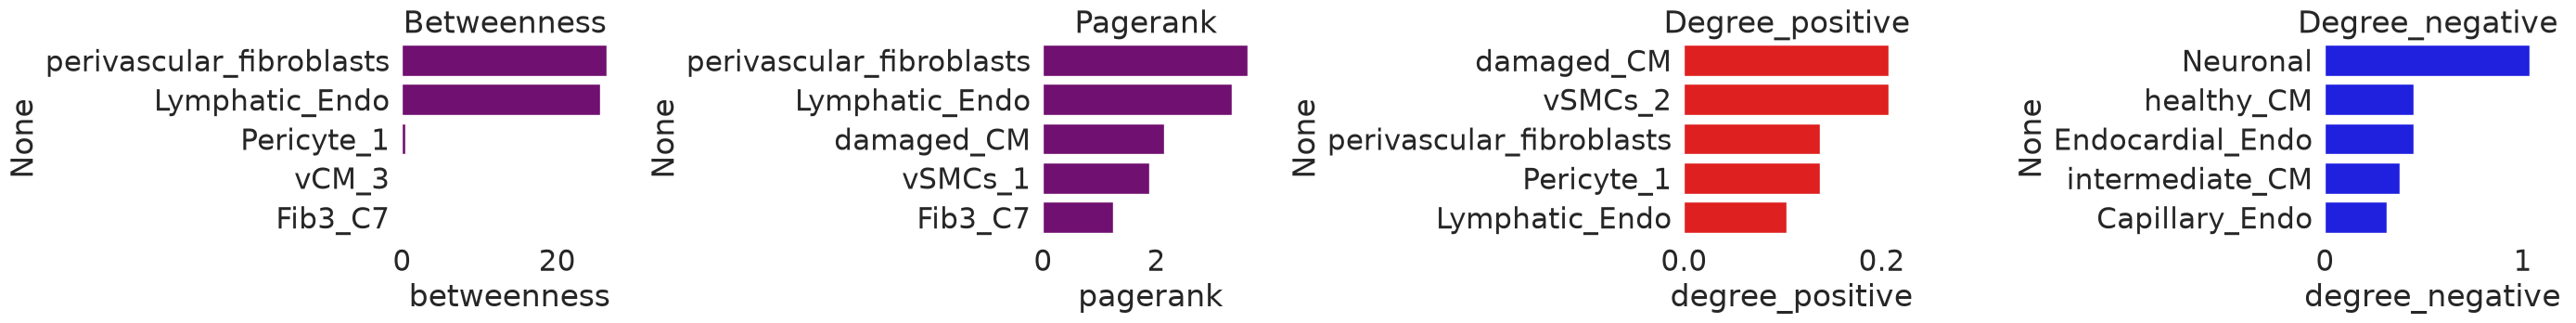

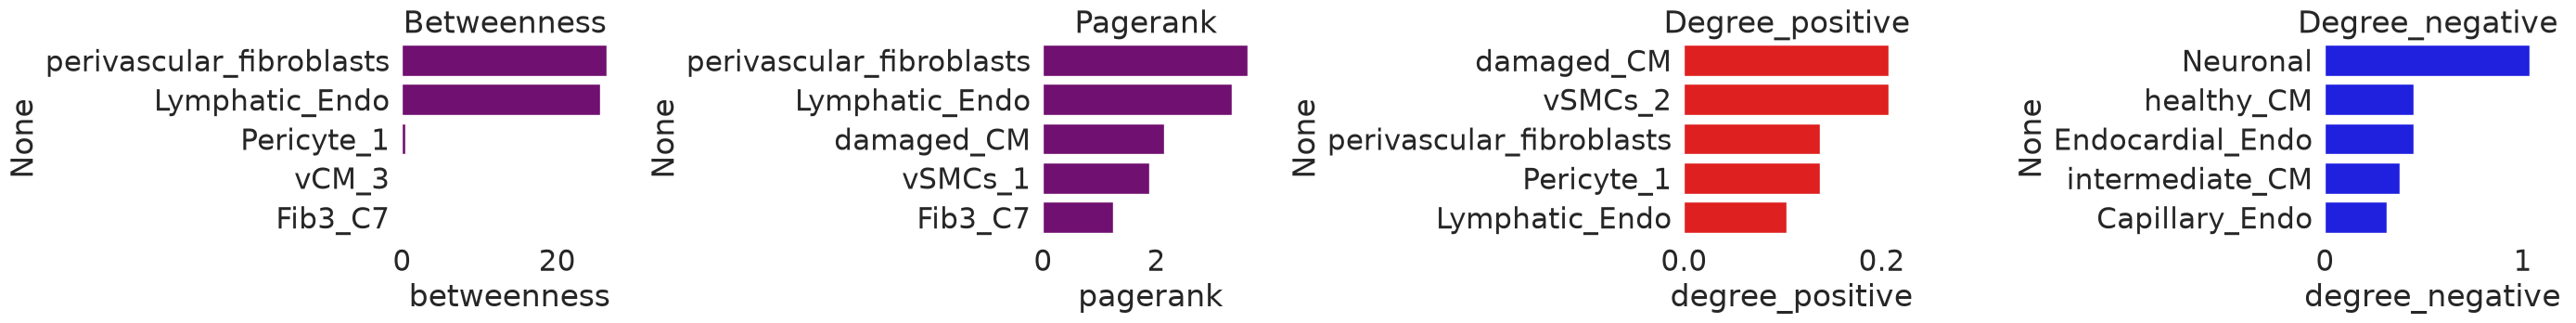

In [47]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = 'None'
nichesphere.tl.plot_top_stats(comm_stats, top_n=5)


## 12. Sankey diagrams

`nichesphere.sankey_plot.plot_custom_sankey` visualises differential LR communication as a four-layer Sankey diagram (source cell type → ligand → receptor → target cell type), built with Plotly. Links are colored by LR score (positive = red, negative = blue).

All filter arguments can be combined: only interactions satisfying all criteria are shown.


Plotting 25 distinct fluid flow paths.


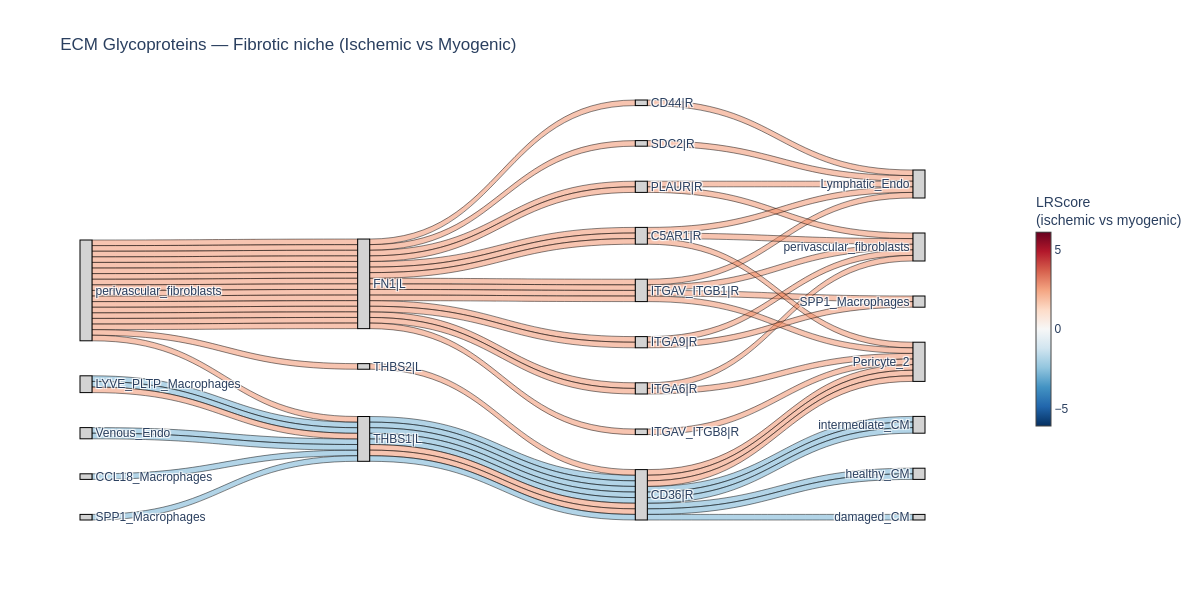

In [48]:
# All ECM glycoprotein interactions from fibrotic niche cell types
ECM_GPs = list(allDBs.Ligand[allDBs.category == 'ECMglycoprots'].str.lower())
fibrotic_cts = niches_dict['4_Fibrotic']

fig = nichesphere.sankey_plot.plot_custom_sankey(
    adata=adata_sc_raw,                   # pass None if using a pre-loaded table (see below)
    table_key='ischemic_x_myogenic',
    filter_df=colocFilt,
    source_cell=fibrotic_cts,
    ligand_list=ECM_GPs,
    threshold=25,
    title='ECM Glycoproteins — Fibrotic niche (Ischemic vs Myogenic)',
    # save_path='figures/fibrotic_ECMglycoprots_sankey.html'
)
fig.show()


Filter to a specific ligand (e.g. SPP1) to trace all its interactions across conditions:

Plotting 25 distinct fluid flow paths.


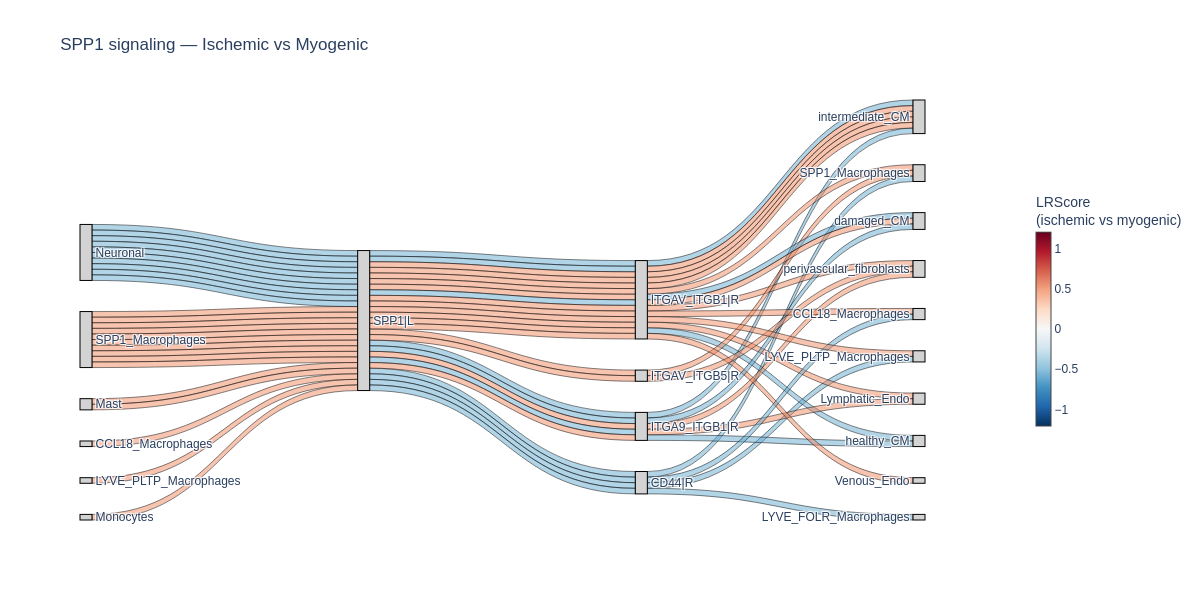

In [49]:
fig = nichesphere.sankey_plot.plot_custom_sankey(
    adata=adata_sc_raw,
    table_key='ischemic_x_myogenic',
    filter_df=colocFilt,
    ligand_gene='SPP1',
    threshold=25,
    title='SPP1 signaling — Ischemic vs Myogenic'
)
fig.show()


---

This concludes the NicheSphere MI Visium tutorial. We have demonstrated:

- Computing cell type co-localization probabilities from Visium deconvolution data
- Testing differential co-localization across conditions and building a co-localization network
- Detecting niches with Louvain community detection and a community-aware layout
- Characterizing niche cohesion with `nichesphere.niche_stats`
- Computing process-based localized differential cell-cell communication from CrossTalkeR data
- Overlaying differential communication onto the co-localization network per process
- Visualizing specific LR interactions with interactive Sankey diagrams

For the PILOT trajectory inference integration, see the companion tutorial: `Nichesphere_tutorial_MIvisium_PILOT.ipynb`.

For further details on individual functions, see the [NicheSphere documentation](https://nichesphere.readthedocs.io).
